**TASK**

An open-source model was imported to detect diseases based on symptoms and provide detailed predictions with recommended treatment

**SUBTASK**

SELECTION OF SUITABLE MODEL

**SUBTASK**

SETUP Model Environment and install required libraries

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

**Reason**:  

The dataset was first collected and prepared as the foundation for the disease detection project.

In [ ]:
data ={
    "Flu":           {"fever":0.1,"cough":0.1,"headache":0.1,"fatigue":0.1,"bp":(110,130),"sugar":(90,130),"sore_throat":0.1,"nausea":0.1,"rash":0.01,'chest-pain':0.1},
    "Diabetes":      {"fever":0.0,"cough":0.0,"headache":0.0,"fatigue":1.0,"bp":(120,200),"sugar":(180,300),"sore_throat":0.0,"nausea":0.0,"rash":0.0,'chest-pain':0.1},
    "Tuberculosis":  {"fever":1.0,"cough":1.0,"headache":1.0,"fatigue":1.0,"bp":(120,160),"sugar":(80,120),"sore_throat":1.0,"nausea":0.0,"rash":0.0,'chest-pain':0.1},
    "Heart Disease": {"fever":0.0,"cough":0.0,"headache":0.0,"fatigue":1.0,"bp":(140,180),"sugar":(100,200),"sore_throat":0.0,"nausea":0.0,"rash":0.0,'chest-pain':0.1},
    "Covid-19":      {"fever":1.0,"cough":1.0,"headache":1.0,"fatigue":1.0,"bp":(110,140),"sugar":(90,150),"sore_throat":1.0,"nausea":1.0,"rash":0.0,'chest-pain':0.1},
    "Cancer":        {"fever":0.0,"cough":0.0,"headache":1.0,"fatigue":1.0,"bp":(120,180),"sugar":(90,250),"sore_throat":0.0,"nausea":0.0,"rash":0.0,'chest-pain':0.1},
    "Asthma":        {"fever":0.0,"cough":1.0,"headache":0.0,"fatigue":1.0,"bp":(110,160),"sugar":(80,150),"sore_throat":0.0,"nausea":0.0,"rash":0.0,'chest-pain':0.1},
    "Migraine":      {"fever":0.0,"cough":0.0,"headache":1.0,"fatigue":0.0,"bp":(110,140),"sugar":(80,120),"sore_throat":0.0,"nausea":0.0,"rash":0.0,'chest-pain':0.1},
    "Dengue":        {"fever":1.0,"cough":0.0,"headache":1.0,"fatigue":1.0,"bp":(100,140),"sugar":(80,150),"sore_throat":0.0,"nausea":1.0,"rash":1.0,'chest-pain':0.1}}

disease ={ 'flu','diabetes','tuberculosis','cancer','covid-19','asthma','migraine','dengue','heart disease'}

print(data)
df = pd.DataFrame(data)
print(df)

{'Flu': {'fever': 0.1, 'cough': 0.1, 'headache': 0.1, 'fatigue': 0.1, 'bp': (110, 130), 'sugar': (90, 130), 'sore_throat': 0.1, 'nausea': 0.1, 'rash': 0.01, 'chest-pain': 0.1}, 'Diabetes': {'fever': 0.0, 'cough': 0.0, 'headache': 0.0, 'fatigue': 1.0, 'bp': (120, 200), 'sugar': (180, 300), 'sore_throat': 0.0, 'nausea': 0.0, 'rash': 0.0, 'chest-pain': 0.1}, 'Tuberculosis': {'fever': 1.0, 'cough': 1.0, 'headache': 1.0, 'fatigue': 1.0, 'bp': (120, 160), 'sugar': (80, 120), 'sore_throat': 1.0, 'nausea': 0.0, 'rash': 0.0, 'chest-pain': 0.1}, 'Heart Disease': {'fever': 0.0, 'cough': 0.0, 'headache': 0.0, 'fatigue': 1.0, 'bp': (140, 180), 'sugar': (100, 200), 'sore_throat': 0.0, 'nausea': 0.0, 'rash': 0.0, 'chest-pain': 0.1}, 'Covid-19': {'fever': 1.0, 'cough': 1.0, 'headache': 1.0, 'fatigue': 1.0, 'bp': (110, 140), 'sugar': (90, 150), 'sore_throat': 1.0, 'nausea': 1.0, 'rash': 0.0, 'chest-pain': 0.1}, 'Cancer': {'fever': 0.0, 'cough': 0.0, 'headache': 1.0, 'fatigue': 1.0, 'bp': (120, 180), 's

**Reason**:

The data types of all features were identified to ensure proper preprocessing and model compatibility

In [ ]:
df.dtypes

,0
Flu,object
Diabetes,object
Tuberculosis,object
Heart Disease,object
Covid-19,object
Cancer,object
Asthma,object
Migraine,object
Dengue,object


# **SUBTASK**

**DATA** **PREPROCESSING**

**Reason**:

Handling Missing Values in which Numerical values are replaced with 0, and categorical values are filled using the mode

In [ ]:
# for numerical columns
df.fillna(0, inplace=True)  #NaN  replace with 0
print(df)
# for categorical columns like datatype (object)   #categorical columns are fever, cough, headache, fatigue etc
df = df.fillna(df.mode().iloc[0])
print(df)

                    Flu    Diabetes Tuberculosis Heart Disease    Covid-19  \
fever               0.1         0.0          1.0           0.0         1.0   
cough               0.1         0.0          1.0           0.0         1.0   
headache            0.1         0.0          1.0           0.0         1.0   
fatigue             0.1         1.0          1.0           1.0         1.0   
bp           (110, 130)  (120, 200)   (120, 160)    (140, 180)  (110, 140)   
sugar         (90, 130)  (180, 300)    (80, 120)    (100, 200)   (90, 150)   
sore_throat         0.1         0.0          1.0           0.0         1.0   
nausea              0.1         0.0          0.0           0.0         1.0   
rash               0.01         0.0          0.0           0.0         0.0   
chest-pain          0.1         0.1          0.1           0.1         0.1   

                 Cancer      Asthma    Migraine      Dengue  
fever               0.0         0.0         0.0         1.0  
cough            

**Reason**:

Duplicate records were removed to ensure clean and unique data.

In [ ]:
df.drop_duplicates()

,Flu,Diabetes,Tuberculosis,Heart Disease,Covid-19,Cancer,Asthma,Migraine,Dengue
fever,0.1,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
cough,0.1,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0
headache,0.1,0.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0
fatigue,0.1,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0
bp,"(110, 130)","(120, 200)","(120, 160)","(140, 180)","(110, 140)","(120, 180)","(110, 160)","(110, 140)","(100, 140)"
sugar,"(90, 130)","(180, 300)","(80, 120)","(100, 200)","(90, 150)","(90, 250)","(80, 150)","(80, 120)","(80, 150)"
sore_throat,0.1,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
nausea,0.1,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
rash,0.01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
chest-pain,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1


**Reason**:  

Label encoding is used to convert categorical values into numeric values.

In [ ]:


# Example dataset
#data = {
    #"fever": [1, 0, 1, 0],
    #"cough": [1, 1, 0, 0],
   # "sugar": [190, 120, 100, 150],
   # "bp": [150, 110, 130, 140],
   # "disease": ["Diabetes", "Flu", "Asthma", "Cancer"]
#}
#df = pd.DataFrame(data)
# Label Encoding
##le = LabelEncoder()
#df["disease_label"] = le.fit_transform(df["disease"])
#print("\nDisease Encoding Mapping:")
#print(dict(zip(le.classes_, le.transform(le.classes_))))

**Reason**: Generates synthetic dataset

In [ ]:
rows = []
for disease, features in data.items():
    for _ in range(10):  # 10 samples per disease
        row = []
        for f in features.values():
            if isinstance(f, float):  # probability → 0 or 1
                value = np.random.choice([0,1], p=[1-f, f])   #f=1 so 1-f=0
            elif isinstance(f, tuple):  # range → sample from tuple
                value = np.random.randint(f[0], f[1]+1)
            else:  # int or already numeric → use as-is
                value = f
            row.append(value)
        row.append(disease)
         # { "fever": 1,"cough": 0,"headache": 1,"fatigue": 1,"bp": 132,"sugar": 190,"sore_throat": 0,"nausea": 0,
         #"rash": 0,"chest-pain": 1,"disease": "Diabetes",'disease':'flu' },
         # rows.append(row)

columns = list(next(iter(data.values())).keys()) + ["disease"]
df = pd.DataFrame(rows, columns=columns)
print(df.head())

**Reason**:

Find out columns of dataset

In [ ]:
print(df.columns)

Index(['fever', 'cough', 'headache', 'fatigue', 'bp', 'sugar', 'sore_throat',
       'nausea', 'rash', 'chest-pain', 'disease'],
      dtype='object')


Reason:



In [ ]:
X = df.drop("disease", axis=1)
y = df["disease"]
# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42,stratify=y)

IndexError: list index out of range

In [ ]:
# Scaling initialize
scaler = MinMaxScaler()
# Fit aur transform training data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
# Model train with scaled data
model.fit(X_train_scaled, y_train)
print("\nEnter patient symptoms (1=yes,0=no):")
fever       = int(input("Fever: "))
cough       = int(input("Cough: "))
headache    = int(input("Headache: "))
fatigue     = int(input("Fatigue: "))
bp          = int(input("Blood Pressure: "))
sugar       = int(input("Sugar Level: "))
sore_throat = int(input("Sore Throat: "))
nausea      = int(input("Nausea: "))
rash        = int(input("Skin Rash: "))
chest_pain  = int(input("Chest Pain (1=yes, 0=no): "))
user_input = pd.DataFrame([[
    fever, cough, headache, fatigue, bp, sugar, sore_throat, nausea, rash, chest_pain
]], columns=X.columns)
user_input_scaled = scaler.transform(user_input)
# . Predict probabilities
probs = model.predict_proba(user_input_scaled)[0]
diseases = model.classes_                          # if you have 3 diseases asthma,flu and diabetes and flu in classes it is representated as
                                                   # asthma,diabetes,and flu show ho ga
#  Show results
results = pd.DataFrame({"Disease": diseases, "Probability": probs})
results = results.sort_values("Probability", ascending=False)
print("\n🔎 Possible Diagnoses:")
print(results)
# Disease → Treatment dictionary
disease_treatment = {
    "Asthma": "Use inhaler, avoid dust & allergens, consult pulmonologist.",
    "Cancer": "Depends on type, usually chemo/radiotherapy, consult oncologist.",
    "Covid-19": "Rest, fluids, paracetamol, isolation, and doctor if severe.",
    "Dengue": "Plenty of fluids, paracetamol, avoid aspirin, hospital if platelets low.",
    "Diabetes": "Sugar control with diet, exercise, insulin/medicines.",
    "Flu": "Rest, warm fluids, paracetamol, consult doctor if fever persists.",
    "Heart Disease": "Low cholesterol diet, medicines, regular checkups, emergency care if chest pain.",
    "Migraine": "Pain relievers, rest in dark room, avoid triggers, consult neurologist.",
    "Tuberculosis": "6–9 months antibiotic course (DOTS), follow doctor strictly."
}

#  Predict final disease
predicted_disease = model.predict(user_input_scaled)[0]
print(f"\n Predicted Diseases: {predicted_disease}")

#  Recommended treatment
print(" Recommended Treatment:",
      disease_treatment.get(predicted_disease))


Enter patient symptoms (1=yes,0=no):


**Reason**:

Accuracy of Naive Bayes Algorithm on disease detection

In [ ]:

model = KNeighborsClassifier(n_neighbors=3)
model = GaussianNB()
model.fit(X_train, y_train)
# 6. Accuracy
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"KNN Accuracy: {accuracy*100:.2f}%")

**Reason**:

Bar chart for disease detection

In [ ]:
top3 = results.head(3)  # take top 3 predictions
plt.figure(figsize=(6,4))
sns.barplot(x="Probability", y="Disease", data=top3, palette="viridis")
plt.title("Top 3 Possible Diseases")
plt.show()

NameError: name 'results' is not defined

R**e**ason:

Pie chart for Disease Detection

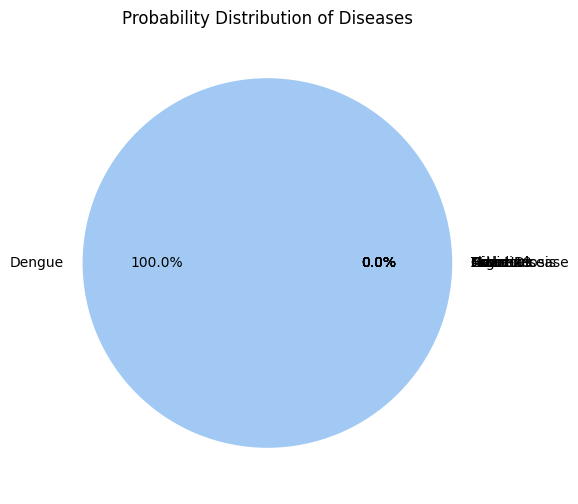

In [ ]:
plt.figure(figsize=(6,6))
plt.pie(results["Probability"], labels=results["Disease"], autopct="%1.1f%%",
        colors=sns.color_palette("pastel"))
plt.title("Probability Distribution of Diseases")
plt.show()

**Reason**:

Heatmap for Disease Detection

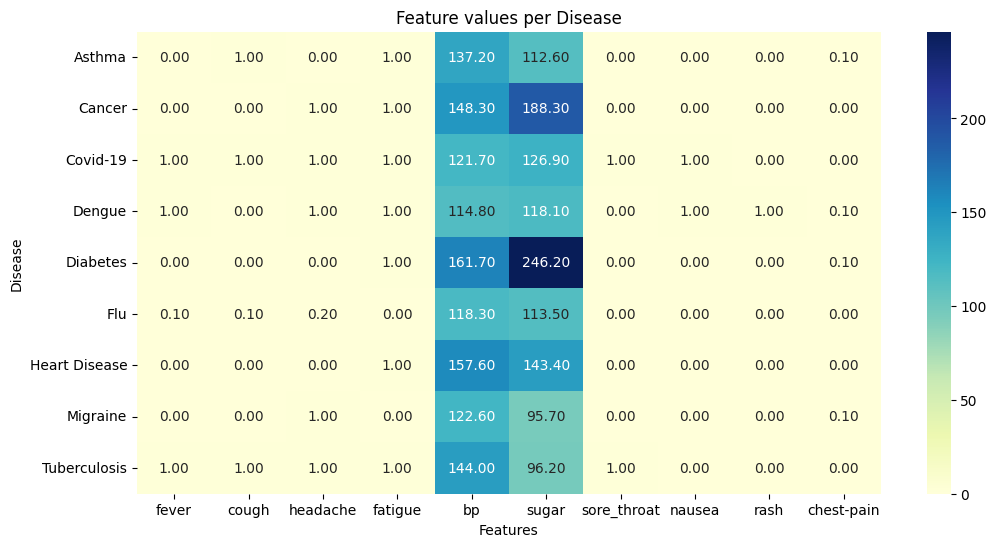

In [ ]:
heatmap_data = df.groupby('disease').mean()
plt.figure(figsize=(12,6))
sns.heatmap(heatmap_data, annot=True, cmap='YlGnBu', fmt=".2f")
plt.title("Feature values per Disease")
plt.xlabel("Features")
plt.ylabel("Disease")
plt.show()